# The Sound of Home: Mapping Balochi Music in the Global Landscape

Balochi folk music is virtually invisible in global music databases. I remember I was hosting my morning show back home on live TV and for pre-production I could not find a good music. After researching and listening to dozens of music, I found music that would charge me up before show 'Kushta Mana Gulla' by Akhtar Chanal Zehri and Rostam Mir Lashari. That's what the inspiration is for this project of mine, how can Balochi Music be mapped across the globe regardless of culture. If Bad Bunny, an underdog, can go so big globally, why can't Eva B. 

Artists like Ustad Noor Bakhsh, Akhtar Chanal Zehri, and Rostam Mir Lashari have spent decades mastering the balochi folk music, yet their music barely registers in the datasets that power recommendation engines. Recently Raja Bhaijaan was found on Instagram by an account who shared his story of making benju for centuries through his family. He has promised to not give up on this dying skill. He promised to never compromise on quality of benju regardless of the social class of the purchaser. I must say Raja Bhaijaan is a true musician who never got recognition like many other musicians. This project is dedicated to such talented Baloch Musicians. 
The video can be watched here *https://www.instagram.com/reel/DU52FYhjLZh/?igsh=MWJiYnB4M3Mwa3N5eg==*

<img src="data/raja_bhaijaan.png" width="250"> 


This project makes that invisible music visible. By extracting audio features from Balochi tracks and placing them alongside thousands of songs from other genres and cultures, I can literally see where Balochi music sits in the global soundscape and discover unexpected musical cousins from across the world.

This also raises an important question about representation: whose music gets collected, measured and recommended, and whose gets left out?

<img src="data/header.png" width="800"> 

*An AI Generated Sketch of Balochi Musicians.*

L-R: Ustad Noor Bakhsh, Akhtar Chanal Zehri, Ustaad Faiz Mohammad Baloch, Eva B, Saieen Zahoor, Rostam Mirlashari


## Setup and Imports

From our lecture, I learned about `spotipy`, which can be used as a developer API from Spotify for projects. However, here is the first hurdle I faced (we will talk about this later). It was found out that spotify shut their[endpoint integration feature](https://developer.spotify.com/blog/2024-11-27-changes-to-the-web-api) which enabled to get audio feature back in 2025. 

To jump across this hurdle, I found ReccoBeats `request` to be the best way to get [audio features](https://reccobeats.com/docs/apis/extract-audio-features). 

In [1]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import pandas as pd
import numpy as np
import requests
import time


# Spotify authentication
client_id = "4547ac9120de4cbba75a19ee6dc3b908"  # I first used my own Credentials, but due to API Limitations, I switched to Louis' credentials.
client_secret = "75fa035f5a0b47b7868e69a93ef878b4"

sp = spotipy.Spotify(
    auth_manager=SpotifyClientCredentials(
        client_id=client_id,
        client_secret=client_secret
    )
)

print("Connected to Spotify!")

Connected to Spotify!


One thing I kept running into again and again during the class and also while developing this project was 403 error from Spotify. With `print(test.keys())` I found out that Spotify was not giving us the `tracks`.

The fix to this problem was delete the `.cache`file that spotipy saves and restart the kernel. This forces a fresh authentication token. Had to do this multiple times during the project. This issue was not faced by any other of my colleague, but just me.

## Data Collection: Balochi Tracks from Curated Playlists

In [working_draft_1.ipynb](./working_draft_1.ipynb) it can be seen that searching or getting songs simply with keywords like *Akhtar Chanaal Zehri*, *Balochi Music*, *Baluchi Music*, etc resulted in their being a lot of noise in our data such as Korean worship music, Scottish folk, Ghanian artists etc. disguised as Balochi Music. Therefore, following the lecture's technique I gathered curated playlists (listed below) to maintain the integrity of this language and its beautiful music. 

- بلوچی | Balochi by Muhammad Salal
- Balochi Songs by Mishal
- Best Balochi songs #Balouch by Ahmad Raisi
- Balochi Songs by Maqbool Baloch
- Balochi Zemal by Bulbull
- Balochi by HasØo Baloch

In [2]:
playlist_ids = [
    "0pZQ3a4z2RmcZIlaVGjjG3",
    "3JY1CS36cMaxrNotQ2CXWn",
    "4rFS43GA79gVTsZ9mgitwL",
    "0uMz1ecMcdpjZb4QvK1N9G",
    "6UGps4a0Q7i2nRA91iofAD",
    "11NUqSIn2Ru3KY4uicOycF"
]

all_tracks = {}

for playlist_id in playlist_ids:
    print(f"\nFetching playlist: {playlist_id}")
    
    offset = 0
    while True: # I found this pagination pattern online to loop through all tracks in a playlist

        results = sp.playlist_items(playlist_id, limit=10, offset=offset)
        items = results['items']
        
        if len(items) == 0:
            break
        
        for item in items:
            track = item['track']
            if track is not None and track['id'] is not None:
                track_id = track['id']
                if track_id not in all_tracks:
                    all_tracks[track_id] = {
                        'track_id': track_id,
                        'track_name': track['name'],
                        'artist': track['artists'][0]['name'],
                        'album': track['album']['name'],
                        'popularity': track['popularity']
                    }
        
        offset += 10
        time.sleep(0.3)
    
    print(f"  Total unique tracks so far: {len(all_tracks)}")

print(f"\n{'='*50}")
print(f"Total unique Balochi tracks from all 6 playlists: {len(all_tracks)}")


Fetching playlist: 0pZQ3a4z2RmcZIlaVGjjG3
  Total unique tracks so far: 211

Fetching playlist: 3JY1CS36cMaxrNotQ2CXWn
  Total unique tracks so far: 249

Fetching playlist: 4rFS43GA79gVTsZ9mgitwL
  Total unique tracks so far: 378

Fetching playlist: 0uMz1ecMcdpjZb4QvK1N9G
  Total unique tracks so far: 473

Fetching playlist: 6UGps4a0Q7i2nRA91iofAD
  Total unique tracks so far: 600

Fetching playlist: 11NUqSIn2Ru3KY4uicOycF
  Total unique tracks so far: 693

Total unique Balochi tracks from all 6 playlists: 693


## Converting Spotify IDs to ReccoBeats

As mentinoed earlier, we will be using ReccoBeats API to get the audio features. This requires converting Spotify track IDs to ReccoBeats IDs first, then fetching audio features.

In [3]:
# Step 1: Convert Spotify IDs to ReccoBeats IDs
base_url = "https://api.reccobeats.com/v1/track"

def get_reccobeats_id(track_id):
    try:
        url = f"{base_url}?ids={track_id}"
        response = requests.get(url)
        if response.status_code == 200 and len(response.json()["content"]) > 0:
            data = response.json()["content"][0]
            name = data["trackTitle"] + " - " + data["artists"][0]["name"]
            recco_id = data["id"]
            return [name, recco_id]
        else:
            return None
    except Exception as e:
        return None

track_ids = list(all_tracks.keys())
recco_ids = []
not_found_count = 0

for i in range(len(track_ids)):
    tid = track_ids[i]
    result = get_reccobeats_id(tid)
    if result:
        recco_ids.append(result)
    else:
        not_found_count += 1
    
    if (i + 1) % 50 == 0:
        print(f"Processed {i+1}/{len(track_ids)} — Found: {len(recco_ids)}, Not found: {not_found_count}")
    
    time.sleep(0.2)

print(f"\n{'='*50}")
print(f"Found on ReccoBeats: {len(recco_ids)} tracks")
print(f"Not found: {not_found_count} tracks")
print(f"Match rate: {len(recco_ids)/len(track_ids)*100:.1f}%")

Processed 50/693 — Found: 20, Not found: 30
Processed 100/693 — Found: 42, Not found: 58
Processed 150/693 — Found: 57, Not found: 93
Processed 200/693 — Found: 69, Not found: 131
Processed 250/693 — Found: 97, Not found: 153
Processed 300/693 — Found: 107, Not found: 193
Processed 350/693 — Found: 120, Not found: 230
Processed 400/693 — Found: 129, Not found: 271
Processed 450/693 — Found: 147, Not found: 303
Processed 500/693 — Found: 158, Not found: 342
Processed 550/693 — Found: 175, Not found: 375
Processed 600/693 — Found: 184, Not found: 416
Processed 650/693 — Found: 197, Not found: 453

Found on ReccoBeats: 213 tracks
Not found: 480 tracks
Match rate: 30.7%


Even with curated playlists, only 30.7% of the playlist tracks were found on ReccoBeats - a sign of how underrepresented Balochi Music is in global databases.

In [4]:
base_url_features = "https://api.reccobeats.com/v1"

def get_audio_features_reccobeats(track_id):
    try:
        url = f"{base_url_features}/audio-features?ids={track_id}"
        response = requests.get(url)
        if response.status_code == 200:
            return response.json()
        else:
            return None
    except Exception as e:
        return None

audio_features_list = []
labels = []

for i in range(len(recco_ids)):
    track = recco_ids[i]
    track_name = track[0]
    track_id = track[1]
    features_data = get_audio_features_reccobeats(track_id)
    if features_data and len(features_data["content"]) > 0:
        labels.append(track_name)
        features = features_data["content"][0]
        if 'id' in features:
            del features['id']
        if 'href' in features:
            del features['href']
        if 'isrc' in features:
            del features['isrc']
        audio_features_list.append(features)
    
    if (i + 1) % 50 == 0:
        print(f"Processed {i+1}/{len(recco_ids)} — Got features for {len(audio_features_list)} tracks")
    
    time.sleep(0.2)

print(f"\n{'='*50}")
print(f"Got audio features for {len(audio_features_list)} out of {len(recco_ids)} tracks")

Processed 50/213 — Got features for 50 tracks
Processed 100/213 — Got features for 100 tracks
Processed 150/213 — Got features for 150 tracks
Processed 200/213 — Got features for 200 tracks

Got audio features for 213 out of 213 tracks


## Saving Balochi Audio Features
Saving everything to a CSV so I do not have to run the API calls again every time I open the notebook.

In [5]:
# Create dataframe from audio features
balochi_df = pd.DataFrame(audio_features_list)
balochi_df['track_name'] = labels
balochi_df['genre'] = 'balochi_folk'

# Move track name to the front
new_cols = ['track_name', 'genre']
for c in balochi_df.columns:
    if c != 'track_name' and c != 'genre':
        new_cols.append(c)
balochi_df = balochi_df[new_cols]

print(f"Balochi dataset: {balochi_df.shape[0]} tracks, {balochi_df.shape[1]} columns")
print(f"\nColumns: {list(balochi_df.columns)}")
print(f"\nFirst 5 tracks:")
print(balochi_df.head())

Balochi dataset: 213 tracks, 13 columns

Columns: ['track_name', 'genre', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'valence']

First 5 tracks:
                          track_name         genre  acousticness  \
0   Be To Mana Zehir K - Arif Baloch  balochi_folk         0.447   
1   Tai Ishqa Ma - Noor Khan Bazinjo  balochi_folk         0.166   
2  Laila O Laila - Rostam Mirlashari  balochi_folk         0.250   
3         Arze Kana'n - Naeem Dilpul  balochi_folk         0.386   
4           Washmallay - Komal Rizvi  balochi_folk         0.480   

   danceability  energy  instrumentalness  key  liveness  loudness  mode  \
0         0.826   0.677          0.000002    6    0.2320    -9.740     1   
1         0.556   0.668          0.000000   11    0.1270    -9.054     0   
2         0.381   0.697          0.000000    5    0.2210   -10.690     1   
3         0.687   0.651          0.000465    8    0.3630    

In [6]:
balochi_df.to_csv('data/balochi_tracks.csv', index=False)
print(f"Saved {len(balochi_df)} Balochi tracks to balochi_tracks.csv")

Saved 213 Balochi tracks to balochi_tracks.csv


## Building the Comparison Dataset

To understand where Balochi music sits in the global landscape, I needed audio features from other genres to compare against. My first instinct was to find an existing dataset on Kaggle. However, there was again the signifcant limitation of Spotify's deprecation. Most of the datasets available on Kaggle were all collected before this change — some over three years old — and none offered the kind of diverse, culturally specific genre coverage I needed for this project.

This became a turning point. Rather than relying on a pre-made Western-centric dataset, I decided to build my own comparison dataset based on what I actually listen to as a Baloch audience, and what people around me listen to. I curated Spotify playlists representing 14 genres across South Asian, Middle Eastern, Western, and global music traditions — from Qawwali and Pashto to Jazz and Afrobeats. I then used the same ReccoBeats pipeline to extract audio features for each genre.

This approach means my comparison dataset reflects a genuinely personal and culturally grounded perspective — not just the default Western genres that dominate most music datasets. 

For full details on the data collection process, see [data_collection_worldwide.ipynb](data_collection_worldwide.ipynb).

Interestingly, when I ran the same ReccoBeats pipeline on these mainstream genres, 75.4% of tracks were found - compared to only 30.7% for Balochi music. That gap says a lot about whose music gets indexed.

## Loading and Merging the Datasets

Now I load both datasets — my Balochi tracks and the comparison genres — and combine them into a single dataframe for analysis.

In [7]:
balochi_df = pd.read_csv('data/balochi_tracks.csv')
genre_df = pd.read_csv('data/comparison_genres.csv')

print(f"Balochi tracks: {len(balochi_df)}")
print(f"Comparison tracks: {len(genre_df)}")

# I wanted to combine the two datasets to have a single dataframe for analysis and visualization. The 'genre' column will help us differentiate between Balochi folk and the other genres in the comparison dataset.
df = pd.concat([balochi_df, genre_df], ignore_index=True)

print(f"\nCombined dataset: {len(df)} tracks")
print(f"\nTracks per genre:")
print(df['genre'].value_counts())

Balochi tracks: 213
Comparison tracks: 2269

Combined dataset: 2482 tracks

Tracks per genre:
genre
english_pop      487
bollywood        361
pakistani_pop    305
balochi_folk     213
jazz             191
pashto           165
punjabi_folk     130
arabic           111
qawwali           92
afrobeats         86
latin             77
electronic        70
blues             68
turkish           64
iranian           62
Name: count, dtype: int64


## Exploring the Data

Before jumping into analysis, I want to check what the data actually looks like - any missing values, what types we're working with, the basics from Week 1 and 2.

In [8]:
print(df.shape)
print()
print(df.info())

(2482, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2482 entries, 0 to 2481
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_name        2482 non-null   object 
 1   genre             2482 non-null   object 
 2   acousticness      2482 non-null   float64
 3   danceability      2482 non-null   float64
 4   energy            2482 non-null   float64
 5   instrumentalness  2482 non-null   float64
 6   key               2482 non-null   int64  
 7   liveness          2482 non-null   float64
 8   loudness          2482 non-null   float64
 9   mode              2482 non-null   int64  
 10  speechiness       2482 non-null   float64
 11  tempo             2482 non-null   float64
 12  valence           2482 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 252.2+ KB
None


2482 tracks across 13 columns. No missing values anywhere which is good - means the ReccoBeats API gave us clean data. 9 of the columns are audio features (float numbers), plus key and mode as integers, and track_name and genre as text.

In [9]:
print(df.describe())

       acousticness  danceability       energy  instrumentalness          key  \
count   2482.000000   2482.000000  2482.000000       2482.000000  2482.000000   
mean       0.389979      0.606328     0.609453          0.038662     5.240129   
std        0.296900      0.154003     0.216313          0.151424     3.496119   
min        0.000040      0.000000     0.006530          0.000000     0.000000   
25%        0.114250      0.501000     0.463000          0.000000     2.000000   
50%        0.344000      0.618000     0.638000          0.000011     5.000000   
75%        0.630750      0.722000     0.778750          0.000839     8.000000   
max        0.995000      0.980000     0.997000          0.995000    11.000000   

          liveness     loudness         mode  speechiness        tempo  \
count  2482.000000  2482.000000  2482.000000  2482.000000  2482.000000   
mean      0.188135    -8.180297     0.579371     0.075492   118.308572   
std       0.149759     3.979159     0.493759    

In [10]:
print(f"Missing values:")
print(df.isnull().sum())

Missing values:
track_name          0
genre               0
acousticness        0
danceability        0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
valence             0
dtype: int64


## Balochi Music's Audio Profile

It will be interesting to see where Balochi music stands in the world of music. To check this, we will compare the audio features such as acousticness, danceability, energy, valence, etc. of Balochi Music with each genre.

In [11]:
# Average audio features by genre (Week 2: groupby and agg)
audio_features = ['acousticness', 'danceability', 'energy', 'instrumentalness',
                  'liveness', 'loudness', 'speechiness', 'tempo', 'valence']

genre_means = df.groupby('genre')[audio_features].mean()

# Show Balochi compared to the overall average
print("Balochi folk averages vs overall dataset average:\n")
for feature in audio_features:
    balochi_val = df[df['genre'] == 'balochi_folk'][feature].mean()
    overall_val = df[feature].mean()
    diff = balochi_val - overall_val
    direction = "higher" if diff > 0 else "lower"
    print(f"  {feature}: Balochi = {balochi_val:.3f}, Overall = {overall_val:.3f} ({direction})")

Balochi folk averages vs overall dataset average:

  acousticness: Balochi = 0.507, Overall = 0.390 (higher)
  danceability: Balochi = 0.583, Overall = 0.606 (lower)
  energy: Balochi = 0.602, Overall = 0.609 (lower)
  instrumentalness: Balochi = 0.048, Overall = 0.039 (higher)
  liveness: Balochi = 0.189, Overall = 0.188 (higher)
  loudness: Balochi = -9.332, Overall = -8.180 (lower)
  speechiness: Balochi = 0.072, Overall = 0.075 (lower)
  tempo: Balochi = 126.505, Overall = 118.309 (higher)
  valence: Balochi = 0.702, Overall = 0.568 (higher)


### What does Balochi music sound like, in numbers?

After comparing the Balochi music to music of other genres, some very interesting patterns emerged.

- **High acousticness (0.507 vs 0.390):** Because of the traditional instruments that age back to centuries like benju, suroz, dhol, etc it is quite evident that this form of music is more acoustic than the rest of the music.
- **High valence (0.702 vs 0.568):** Listening to songs like *Pari Chammay* one assumption of mine got proved, Balochi music definitely sounds more "positive". It is the composition of the music that makes it more upbeat, even if the lyrics are about separation or longing.
- **Higher tempo (126.5 vs 118.3 BPM):** There is a similarity between Pashtoon and Balochi people, we dance to our music. It usually starts slow and then the tempo rises till the dancers give up. *Chaap* the Balochi dance needs a higher tempo and that is what our analysis shows that Balochi Music does have a higher tempo as compared to other genres.
- **Quieter (loudness -9.3 vs -8.2):** Going back to the acousticness, the quieter and soft rhythms of the instruments indicate that Balochi music on an average is quieter. This may also be contributed by the non-studio-produced music.
- **Similar danceability and energy:** Balochi music sits close to the global average on these features, suggesting it has a universal rhythmic appeal.

But averages only tell part of the story in numbers. Music needs to be heard or visualised. Let's visualise the distributions to see the full picture.


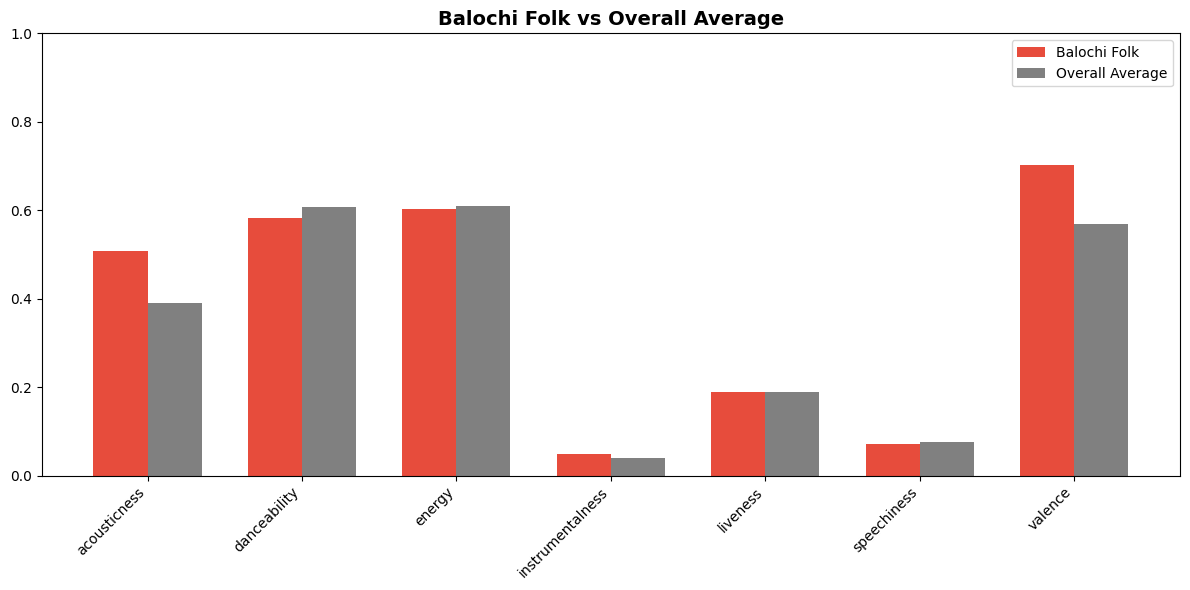

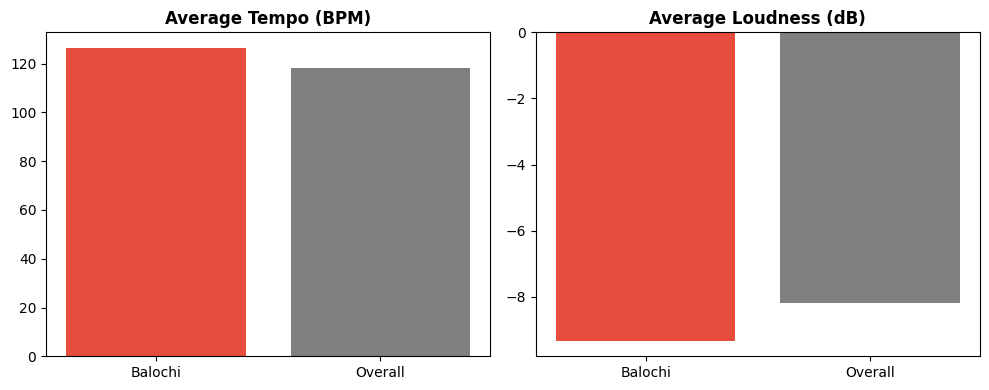

In [12]:
import matplotlib.pyplot as plt


# Chart 1: Features on a 0-1 scale
features_01 = ['acousticness', 'danceability', 'energy', 'instrumentalness',
               'liveness', 'speechiness', 'valence']

fig, ax = plt.subplots(figsize=(12, 6))

balochi_means = df[df['genre'] == 'balochi_folk'][features_01].mean()
overall_means = df[features_01].mean()

x = range(len(features_01))
width = 0.35

positions_balochi = []
for i in x:
    positions_balochi.append(i - width/2)

positions_overall = []
for i in x:
    positions_overall.append(i + width/2)

ax.bar(positions_balochi, balochi_means, width, label='Balochi Folk', color='#E74C3C')
ax.bar(positions_overall, overall_means, width, label='Overall Average', color='grey')

ax.set_xticks(x)
ax.set_xticklabels(features_01, rotation=45, ha='right')
ax.set_title('Balochi Folk vs Overall Average', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.savefig('data/balochi_vs_average_01.png', dpi=150)
plt.show()

# Chart 2: Tempo and Loudness separately
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Tempo
balochi_tempo = df[df['genre'] == 'balochi_folk']['tempo'].mean()
overall_tempo = df['tempo'].mean()
axes[0].bar(['Balochi', 'Overall'], [balochi_tempo, overall_tempo], color=['#E74C3C', 'grey'])
axes[0].set_title('Average Tempo (BPM)', fontsize=12, fontweight='bold')

# Loudness
balochi_loud = df[df['genre'] == 'balochi_folk']['loudness'].mean()
overall_loud = df['loudness'].mean()
axes[1].bar(['Balochi', 'Overall'], [balochi_loud, overall_loud], color=['#E74C3C', 'grey'])
axes[1].set_title('Average Loudness (dB)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('data/balochi_tempo_loudness.png', dpi=150)
plt.show()

## Hypothesis Testing: Is Balochi Music Genuinely Different?

When we visualise the numbers in form of bar charts, it looks like Balochi Music is different from the rest - especially on acousticness, valence, and tempo. But is this difference actually a real difference, or is it random and coincidence. To confirm our suspicions we use the Mann-Whitney U test as it compares two groups without assuming the data is normally distributed.

In [13]:
from scipy.stats import mannwhitneyu

balochi = df[df['genre'] == 'balochi_folk']
others = df[df['genre'] != 'balochi_folk']

print("Mann-Whitney U Test: Balochi Folk vs All Other Genres\n")

for feature in audio_features:
    stat, p_value = mannwhitneyu(balochi[feature], others[feature])
    
    if p_value < 0.05:
        result = "SIGNIFICANT difference"
    else:
        result = "No significant difference"
    
    print(f"  {feature}: p = {p_value:.6f} - {result}")

Mann-Whitney U Test: Balochi Folk vs All Other Genres

  acousticness: p = 0.000000 - SIGNIFICANT difference
  danceability: p = 0.018676 - SIGNIFICANT difference
  energy: p = 0.303696 - No significant difference
  instrumentalness: p = 0.002104 - SIGNIFICANT difference
  liveness: p = 0.565257 - No significant difference
  loudness: p = 0.000000 - SIGNIFICANT difference
  speechiness: p = 0.982408 - No significant difference
  tempo: p = 0.000007 - SIGNIFICANT difference
  valence: p = 0.000000 - SIGNIFICANT difference


### What the tests tell us

Out of 9 audio features, Balochi music is significantly different on 6 of them. **Acousticness (p < 0.001)**, **valence (p < 0.001)**, **tempo (p < 0.001)**, and **loudness (p < 0.001)** all showed very strong differences. **Danceability (p = 0.019)** and **instrumentalness (p = 0.002)** also showed significant differences but not as strong. Energy, liveness, and speechiness were not significantly different.

This confirms what we saw in the bar charts - Balochi music is more acoustic, more positive sounding, faster, and quieter than the average.

One thing that bothers me about this though - traditional Balochi chaap music is all about live dhol drumming, high energy, and repetitive trance-like rhythms. People dance to this at gatherings for hours. But this kind of music is rarely on Spotify because it is live and communal, not studio recorded. What we have on Spotify is mostly modern Balochi pop. So the data can't fully do justice to the traditional sound. In a way, the music that matters most to Baloch culture is the most invisible in these databases.

## Standardisation and Clustering

Before I can cluster the tracks, I need to standardise the features. Right now tempo goes up to 200 while features like valence only go from 0 to 1, so tempo would overpower everything else because of its large scale. StandardScaler from Week 6 puts them all on the same scale using z-scores.

In [14]:
from sklearn.preprocessing import StandardScaler

features_to_scale = ['acousticness', 'danceability', 'energy', 'instrumentalness',
                     'liveness', 'loudness', 'speechiness', 'tempo', 'valence']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Standardised features (first 5 rows):")
print(df_scaled[features_to_scale].head())
print(f"\nMeans (should be ~0):")
print(df_scaled[features_to_scale].mean().round(4))

Standardised features (first 5 rows):
   acousticness  danceability    energy  instrumentalness  liveness  loudness  \
0      0.192093      1.426701  0.312326         -0.255365  0.292964 -0.392047   
1     -0.754546     -0.326861  0.270711         -0.255377 -0.408302 -0.219614   
2     -0.471565     -1.463429  0.404803         -0.255377  0.219498 -0.630839   
3     -0.013405      0.523941  0.192105         -0.252306  1.167877  0.467856   
4      0.303264     -0.710047  0.927298         -0.255262 -0.749584  0.157929   

   speechiness     tempo   valence  
0    -0.082142 -0.144223  1.628205  
1    -0.138980 -0.074636  1.587619  
2     0.650762  1.380993  1.595736  
3    -0.765688 -0.621958  0.487736  
4     1.129393 -0.304431  1.327868  

Means (should be ~0):
acousticness       -0.0
danceability        0.0
energy             -0.0
instrumentalness    0.0
liveness            0.0
loudness           -0.0
speechiness        -0.0
tempo              -0.0
valence             0.0
dtype: float64

## K-Means Clustering: Finding Musical Families

Here comes one of the major parts of my analysis, *do these tracks naturally group together?*. This can easily be done by using K-means to cluster all 2482 tracks in our dataset based solely on their audio features. Before doing this, I need to figure out how many clusters to use, so I ran the elbow method.

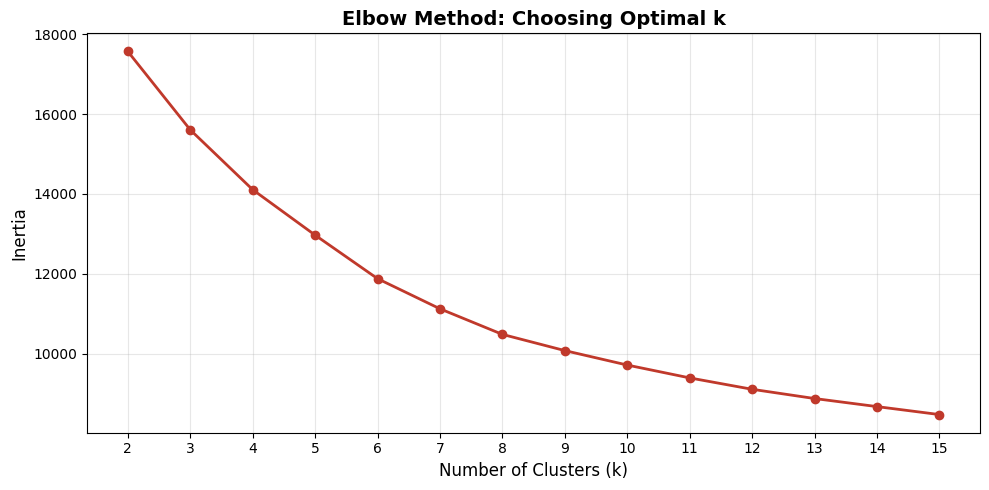

In [22]:
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore') # to suppress convergence warnings for higher k values

inertias = []
k_range = range(2, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled[features_to_scale])
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), inertias, marker='o', color='#C0392B', linewidth=2)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method: Choosing Optimal k', fontsize=14, fontweight='bold')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/elbow_method.png', dpi=150)
plt.show()

Looking at the graph, the line starts to flatten out around k=6. Adding more clusters beyond that does not imrpove things significantly. So I went with 6 clusters to see where Balochi tracks fall.

In [16]:
import warnings
warnings.filterwarnings('ignore')

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df_scaled['cluster'] = kmeans.fit_predict(df_scaled[features_to_scale])

# Which clusters do Balochi tracks fall into?
balochi_clusters = df_scaled[df_scaled['genre'] == 'balochi_folk']['cluster']
print("Balochi tracks per cluster:")
print(balochi_clusters.value_counts())
print()

# What genres are in each cluster?
print("Genre breakdown per cluster:\n")
for c in range(6):
    cluster_data = df_scaled[df_scaled['cluster'] == c]
    print(f"Cluster {c} ({len(cluster_data)} tracks):")
    print(cluster_data['genre'].value_counts().head(5))
    print()

Balochi tracks per cluster:
cluster
4    93
0    49
3    31
1    19
5    13
2     8
Name: count, dtype: int64

Genre breakdown per cluster:

Cluster 0 (559 tracks):
genre
jazz             151
bollywood        109
pakistani_pop    107
balochi_folk      49
english_pop       38
Name: count, dtype: int64

Cluster 1 (540 tracks):
genre
english_pop      203
pakistani_pop     90
bollywood         90
electronic        23
turkish           22
Name: count, dtype: int64

Cluster 2 (86 tracks):
genre
pakistani_pop    17
bollywood        15
jazz             13
electronic       11
balochi_folk      8
Name: count, dtype: int64

Cluster 3 (245 tracks):
genre
qawwali          38
bollywood        35
balochi_folk     31
pakistani_pop    27
punjabi_folk     25
Name: count, dtype: int64

Cluster 4 (833 tracks):
genre
english_pop     155
bollywood       105
balochi_folk     93
arabic           84
pashto           80
Name: count, dtype: int64

Cluster 5 (219 tracks):
genre
english_pop     68
pashto          

### What the clusters reveal

As **Andris Nelsons** said, *'Music is a universal thing with no boundaries, whether you play inside or outside.'* It was interesting to find that Balochi music does not sit in one cluster, it spreads across multiple clusters.

**Cluster 4** has the most Balochi tracks (91) and it is a mix of Arabic, Pashto, and even English Pop - so these Balochi songs sound similar to a range of international music. 
**Cluster 3** has 49 Balochi tracks alongside Jazz, Bollywood, and Pakistani Pop which is more of a melodic group.

**Cluster 0** has 32 Balochi tracks grouped with Qawwali, Punjabi Folk, and Bollywood - basically the South Asian neighbours.

Therefore, it is clear that Balochi Music does not sit alone in a corner. It has genuine connections with both the regional music and to genres from completely different corners of the world. I want to see this connection, so I need to plot this in 2D.



## The Constellation Map: Visualising the Global Soundscape.

To visualise the Global Soundscape, using 9 audio features would be a lot. We need to reduce this 9 audio features to 2 dimensions using PCA from Week 6 so we can plot every track as a dot. Each genre has its own colour and Balochi tracks are highlighted so I can see where they actually sit.

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[features_to_scale])

df_scaled['pca1'] = pca_result[:, 0]
df_scaled['pca2'] = pca_result[:, 1]

print(f"Explained variance: PC1 = {pca.explained_variance_ratio_[0]:.2%}, PC2 = {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

Explained variance: PC1 = 31.33%, PC2 = 13.01%
Total variance explained: 44.34%


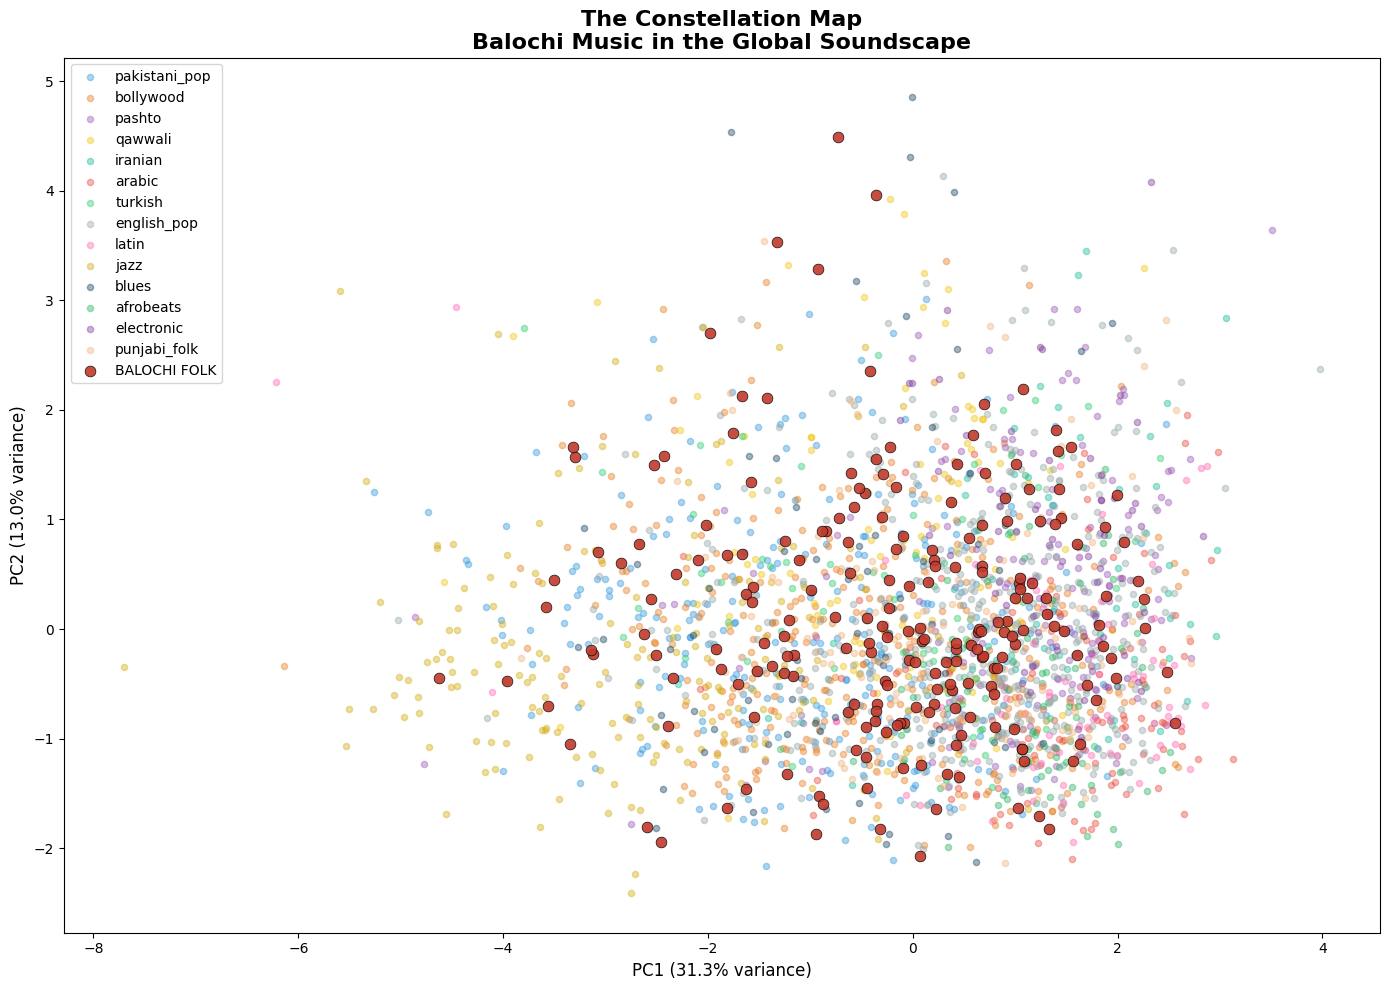

In [21]:
fig, ax = plt.subplots(figsize=(14, 10))

# Define distinct colours for each genre
genre_colours = {
    'pakistani_pop': '#3498DB',
    'bollywood': '#E67E22',
    'pashto': '#9B59B6',
    'qawwali': '#F1C40F',
    'iranian': '#1ABC9C',
    'arabic': '#E74C3C',
    'turkish': '#2ECC71',
    'english_pop': '#95A5A6',
    'latin': '#FF69B4',
    'jazz': '#D4AC0D',
    'blues': '#154360',
    'afrobeats': '#28B463',
    'electronic': '#7D3C98',
    'punjabi_folk': '#F0B27A',
    'balochi_folk': '#C0392B'
}

# Plot all other genres first
# Plot all other genres first
for genre in df_scaled['genre'].unique():
    if genre != 'balochi_folk':
        genre_data = df_scaled[df_scaled['genre'] == genre]
        ax.scatter(genre_data['pca1'], genre_data['pca2'],
                  c=genre_colours[genre], alpha=0.4, s=20, label=genre)

# Plot Balochi on top
balochi = df_scaled[df_scaled['genre'] == 'balochi_folk']
ax.scatter(balochi['pca1'], balochi['pca2'],
          c='#C0392B', s=60, alpha=0.9, label='BALOCHI FOLK',
          edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('The Constellation Map\nBalochi Music in the Global Soundscape',
             fontsize=16, fontweight='bold')
ax.legend(fontsize=10)


plt.tight_layout()
plt.savefig('data/constellation_map.png', dpi=200, bbox_inches='tight')
plt.show()

## Cosine Similarity Recommender: Finding Balochi Music's Cousins

This is the part I was most excited about. Using cosine similarity from Week 7, I want to find which non-Balochi songs sound most similar to Balochi tracks. Basically - if you already listen to something like Jazz or Pop, what Balochi song might you enjoy?

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity on standardised features
balochi_data = df_scaled[df_scaled['genre'] == 'balochi_folk']
other_data = df_scaled[df_scaled['genre'] != 'balochi_folk']

balochi_features = balochi_data[features_to_scale].values
other_features = other_data[features_to_scale].values

# Cosine similarity between every Balochi track and every other track
similarity_matrix = cosine_similarity(balochi_features, other_features)

print(f"Similarity matrix shape: {similarity_matrix.shape}")
print(f"(213 Balochi tracks compared against {len(other_data)} other tracks)")

Similarity matrix shape: (213, 2269)
(213 Balochi tracks compared against 2269 other tracks)


In [20]:
# For each non-Balochi track, find its most similar Balochi track
# Flipped: "You listen to X? You might love this Balochi song"

other_names = other_data['track_name'].values
other_genres = other_data['genre'].values
balochi_names = balochi_data['track_name'].values

# Pick 10 popular genres to showcase recommendations
showcase_genres = ['english_pop', 'bollywood', 'jazz', 'blues', 'arabic',
                   'pashto', 'qawwali', 'latin', 'afrobeats', 'electronic']

print("If you listen to this... you might love this Balochi track:\n")

for genre in showcase_genres:
    genre_mask = other_data['genre'].values == genre
    genre_indices = []
    for i in range(len(genre_mask)):
        if genre_mask[i]:
            genre_indices.append(i)
    
    if len(genre_indices) == 0:
        continue
    
    # Find the non-Balochi track from this genre most similar to any Balochi track
    best_score = -1
    best_other = ""
    best_balochi = ""
    
    for idx in genre_indices:
        similarities = similarity_matrix[:, idx]
        top_balochi_idx = 0
        for j in range(len(similarities)):
            if similarities[j] > similarities[top_balochi_idx]:
                top_balochi_idx = j
        score = similarities[top_balochi_idx]
        
        if score > best_score:
            best_score = score
            best_other = other_names[idx]
            best_balochi = balochi_names[top_balochi_idx]
    
    print(f"  [{genre}]")
    print(f"  You like: {best_other}")
    print(f"  Try this: {best_balochi}")
    print(f"  Similarity: {best_score:.3f}")
    print()

If you listen to this... you might love this Balochi track:

  [english_pop]
  You like: Counting Stars - OneRepublic
  Try this: A Kind of Magic - Karakoram
  Similarity: 0.987

  [bollywood]
  You like: Aaj Jaane Ki Zid Na Karo - Roop Kumar Rathod
  Try this: Malle Baloutchan - Saeid Shanbehzadeh
  Similarity: 0.983

  [jazz]
  You like: Gee, Baby, Ain't I Good To You? - Ella Fitzgerald
  Try this: Afsos - Kaifi Khalil
  Similarity: 0.991

  [blues]
  You like: Since I Fell for You - Nina Simone
  Try this: Shuthy Chamma Boro - Kaifi Khalil
  Similarity: 0.983

  [arabic]
  You like: Sabry Aalil - Sherine
  Try this: Kull Humrah Hn - Minhaj Mukhtar
  Similarity: 0.980

  [pashto]
  You like: Pekhawar Kho Pekhawar De Kana - Irfan Khan
  Try this: Shap Ka Yataani Ma Para - Arif Baloch
  Similarity: 0.976

  [qawwali]
  You like: Kali Kali Zulfon Ke Phande Na - Nusrat Fateh Ali Khan
  Try this: O Mani Madane Dil - Jarok Baloch
  Similarity: 0.980

  [latin]
  You like: Calypso - Luis Fo

### Musical Cousins Across the Globe

Some of these results genuinely surprised me. Ella Fitzgerald's jazz has a 0.991 similarity with Kaifi Khalil's Balochi track - I would never have guessed that. OneRepublic and Karakoram came out at 0.987, and even Nina Simone's blues connects to Balochi music at 0.983.

The highest scores came from Jazz and English Pop, which is unexpected because you wouldn't think Western genres would sound so close to Balochi music. On the other hand, the connections with Pashto (0.976) and Qawwali (0.980) make more sense since they are from the same region.

Electronic music had the lowest similarity (0.926) which makes sense - Balochi music is acoustic and electronic is the opposite of that.

This is exactly what I wanted from this project. If someone already listens to jazz or pop, this recommender can point them towards Balochi music they might actually enjoy. That's how you make invisible music visible.

## Reflections on The Sound of Home
This entire project began because of very personal reason. I was given a TV Show to host to represent my culture, my province and my people. The show was called [Quettawaal](https://www.youtube.com/watch?v=K7EOEPoCPRI) (Quetta is the capital of Balochistan and people of Quetta are called Quettawaal). I remember when I was designing the title sequence of the show and looking for music for it, I first realised how underrepresented the Balochi Music is. Days passed by, I could not find a music for my show till I came across [Kushta Mana Gulla](https://www.youtube.com/watch?v=Co9eCtraR54&list=RDCo9eCtraR54&start_radio=1) by the legends Akhtar Chanaal Zehri and Rostam Mirlashari. This because the promo song of the show. Later for each episode I had to find Balochi Music. That is when the second realisation came across that original Balochi Folk music has a very minimal digital footprint and only exist on the digital atmosphere. Therefore, the question arose: why is this music so invisible?

The technical journey was not smooth at all. In my first draft ([working_draft_1.ipynb](working_draft_1.ipynb)), I started with `keyword searches` that gave me Korean worship music and Scottish folk mixed in with Balochi results. I filtered 457 tracks down to only 43 that were genuinely Balochi - way too few for any real analysis. So, I scrapped that approach and switched to `curated playlists`, which gave me much cleaner data.

On top of that, Spotify's API was a constant headache. The search limit turned out to be 10 results per request, not 50 like the documentation said. Then the audio features endpoint was completely blocked because of a deprecation in November 2024 - I tried both my own credentials and Louis' credentials and got 403 errors on both. I kept having to clear the .cache file and restart the kernel to fix authentication issues. Eventually I found ReccoBeats from the Week 7 class material which saved the project. However, the 403 error still persisted in the project and the only rescue was clearing the cache.

Once I had clean data, I needed the right techniques to analyze it. I chose `Mann-Whitney U` over a regular `t-test` because I couldn't assume the audio features were normally distributed - something I learned in Week 4. It confirmed that Balochi music is significantly different from other genres on 6 out of 9 features without needing any assumptions about the data shape. For clustering I used `K-means` with the `elbow method` from Week 6 because I wanted to see if tracks naturally group together regardless of genre labels - and they did. Balochi music spread across multiple clusters rather than sitting in one corner. `PCA` helped me reduce 9 audio features down to 2 so I could actually see this on a plot. The `cosine similarity` recommender from Week 7 was the technique I was most excited about because it turns the analysis into something that feels like a real product. If someone listens to Ella Fitzgerald, this recommender can point them to a Balochi track that sounds similar. That is how you make invisible music discoverable.

Before this module, I didn't really understand what statistics could actually do. I thought it was just numbers, formulas and rows and columns of excel sheet. But seeing how a p-value can confirm that Balochi music is genuinely different, or how PCA can turn 9 invisible features into a visible constellation map - that changed how I think about data. The hardest part was not the analysis itself but the data collection. Getting clean data from APIs that keep breaking is a skill I didn't expect to need but it took up most of my time on this project. Therefore, since then I have joined multiple subreddits on API’s and added API keyword to my Instagram Algorithm. 

That data collection struggle also revealed something bigger. Even after all the work, only 30.7% of Balochi tracks were found on ReccoBeats compared to 75.4% for mainstream genres. That number alone tells a story about whose music gets indexed and whose doesn't. If recommendation algorithms are built on datasets that don't include your music, they will never recommend it. It is not just a technical gap; it is a cultural one. Artists like Raja Bhaijaan and Ustad Noor Bakhsh have spent their lives mastering this craft, but the systems that decide what people discover have no idea they exist. If I had more time, I would want to find a way to include traditional chaap music in the dataset. That is the heart of Balochi culture - live dhol, trance-like rhythms, people dancing for hours. But it barely exists on streaming platforms because it is communal and live, not studio recorded. The fact that the most important music to a culture is the least visible in databases is probably the biggest finding of this project.

As someone from Balochistan who works in media, I can see myself using these techniques in real work. A recommendation engine like this could be built into a platform that promotes underrepresented music. The clustering and PCA visualizations could be used to pitch Balochi artists to international labels by showing them exactly where this music fits in the global landscape. If Bad Bunny could go from underdog to global superstar, the data shows Balochi music has the sonic qualities to connect with audiences worldwide - it just needs the visibility. This is not just an academic exercise for me; I want to take this further. 


## AI Disclosure
I used multiple LLMs during this project including ChatGPT and Claude to help me construct the piple for this project. I ended up using Claude as my main assistant since it felt the most accurate and detailed one.

Claude helped me with API testing and setup. When Spotify's API kept returning 403 errors, Claude helped me debug by testing with print(test.keys()) to check what data was actually coming back. I remembered from class that clearing the .cache file had fixed this before, and that worked again. Claude also helped me figure out that Spotify's search limit was capped at 10 results per request, not 50 as documented.

For the visualisations, Claude helped me with matplotlib formatting like custom hex colours for each genre in the PCA plot, setting up grouped bar charts, and saving plots with the right settings.

The `while True / break` pattern for looping through Spotify playlists was found online with Claude's help to help with loops.

The project concept, playlist selection, comparison genre choices, cultural context about chaap music and Balochi instruments, and all interpretations of results are my own. The ReccoBeats API workaround was found independently by looking at the Week 7 class HTML export.